# Customer Shopping Behavior Analysis

## 1. Data Loading

In this step, we load the customer shopping behavior dataset into a Pandas DataFrame. 
This dataset contains transactional and demographic information used to analyze customer 
purchasing patterns and business performance.

In [1]:
import pandas as pd
df = pd.read_csv('../data/customer_shopping_behavior.csv')
import matplotlib.pyplot as plt
import seaborn as sns

### Initial Data Preview

We examine the first few rows of the dataset to understand the structure, 
column names, and sample values.


In [2]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


### Dataset Structure and Data Types

This step helps identify:
- Number of records and columns
- Data types of each column
- Presence of missing values


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

### Summary Statistics

We analyze summary statistics of numerical variables to understand:
- Central tendency (mean, median)
- Dispersion (standard deviation)
- Potential anomalies or outliers


In [2]:
df.describe(include='all')

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3863.000000,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,675,2223,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.750065,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.716983,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


## 2. Missing Value Analysis

We check for missing values across all columns to determine 
whether data cleaning or imputation is required.


In [5]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

We assume customer ratings are influenced by product category; therefore, missing values 
are imputed using the median rating within each category to reduce bias from extreme values.

In [6]:
df['Review Rating'] = df.groupby('Category')['Review Rating'].transform(lambda x: x.fillna(x.median()))

### Missing Values After Treatment

After applying imputation, we recheck the dataset to confirm 
that missing values have been handled successfully.


In [7]:
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [8]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [9]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount_(usd)', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='object')

In [10]:
df = df.rename(columns={'purchase_amount_(usd)':'purchase_amount'})

In [11]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='object')

## 3. Feature Engineering – Age Group Creation

To improve demographic analysis and business interpretability, we segment customers 
into age groups. Age-based segmentation allows the business to tailor marketing strategies 
and product offerings to different life stages.

The following age groups are defined based on common retail demographic segmentation:

- Young Adult: 18–25  
- Adult: 26–40  
- Middle Aged: 41–60  
- Senior: 61 and above

In [12]:
bins = [0, 25, 40, 60, 100]
labels = ['Young Adult', 'Adult', 'Middle Aged', 'Senior']

df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

### Validation of Age Group Assignment

We verify that age values are correctly mapped to their respective age groups.


In [13]:
df[['age', 'age_group']].head(10)

,age,age_group
0,55,Middle Aged
1,19,Young Adult
2,50,Middle Aged
3,21,Young Adult
4,45,Middle Aged
5,46,Middle Aged
6,63,Senior
7,27,Adult
8,26,Adult
9,57,Middle Aged


### Customer segment creation

Create customer segmentation based on purchase frequency.

In [33]:
conditions = [
    df['previous_purchases'] == 1,
    df['previous_purchases'].between(2, 10),
    df['previous_purchases'] > 10
]

choices = ['New', 'Returning', 'Loyal']

df['customer_segment'] = np.select(
    conditions,
    choices,
    default='Unknown'
)

customer_segment = (
    df.groupby('customer_segment')['customer_id']
    .count()
)
customer_segment

customer_segment
Loyal        3116
New            83
Returning     701
Name: customer_id, dtype: int64

## Insight

- The majority of customers (**3,116**) belong to the **Loyal** segment, indicating a strong and stable repeat customer base.

- A significant number of customers (**701**) are classified as **Returning**, showing good retention performance with strong potential to convert them into loyal customers through targeted engagement strategies.

- A very small portion (**83**) are **New** customers, suggesting that the business currently relies more on repeat purchases than on new customer acquisition.

### Overall Interpretation

The high proportion of **Loyal customers** reflects strong customer satisfaction and effective retention strategies. However, the relatively low number of **New customers** highlights an opportunity to improve marketing and customer acquisition efforts to ensure long-term business growth.

## 4. Exploratory Data Analysis (EDA)

In this section, we explore customer behavior, purchasing patterns, and revenue drivers 
using descriptive statistics and visual analysis. The goal is to extract insights that 
can support business decision-making.


In [52]:
df['gender'].value_counts()
df['discount_applied'].value_counts()
df['promo_code_used'].value_counts()

promo_code_used
No     2223
Yes    1677
Name: count, dtype: int64

**Values are consistent (Yes/No, Male/Female), no normalization required.**

### Distribution of Customers by Age Group

In [53]:
df['age_group'].value_counts()

age_group
Middle Aged    1503
Adult          1103
Senior          723
Young Adult     571
Name: count, dtype: int64

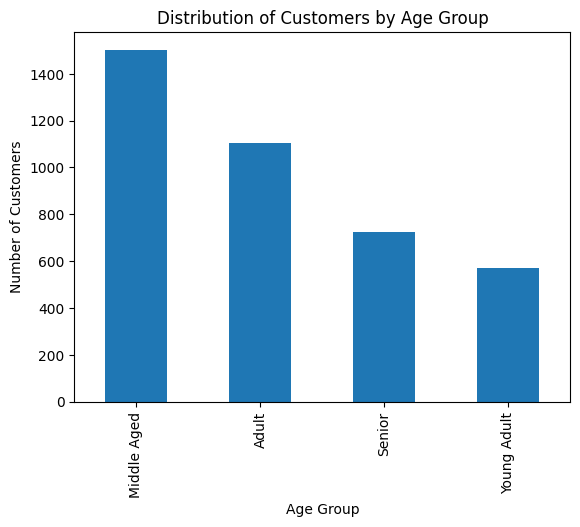

In [54]:
plt.figure()
df['age_group'].value_counts().plot(kind='bar')
plt.title('Distribution of Customers by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.show()

Adult and Middle Aged customers form the largest customer segments, indicating that 
the business primarily caters to working-age consumers with higher purchasing power. 
Young Adult and Senior segments represent smaller but important customer groups.

### Revenue Contribution by Age Group

This analysis evaluates which age groups contribute the most to total revenue, 
helping prioritize high-value customer segments.


In [55]:
age_group_revenue = (
    df.groupby('age_group')['purchase_amount']
    .sum()
    .sort_values(ascending=False)
)
age_group_revenue

C:\Users\mohda\AppData\Local\Temp\ipykernel_3700\2121822882.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_group')['purchase_amount']


age_group
Middle Aged    89445
Adult          65842
Senior         43164
Young Adult    34630
Name: purchase_amount, dtype: int64

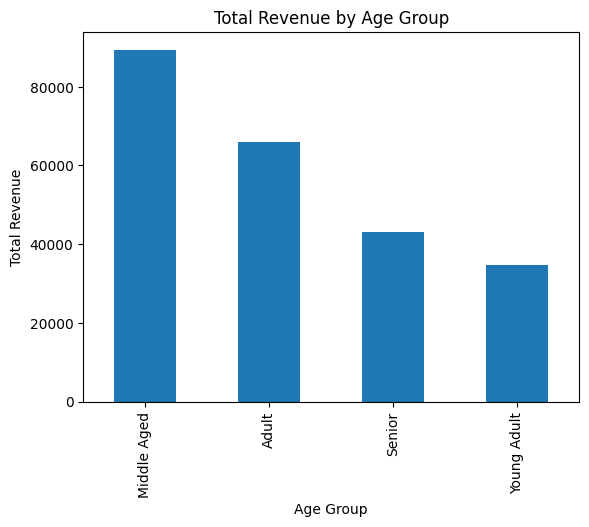

In [56]:
plt.figure()
age_group_revenue.plot(kind='bar')
plt.title('Total Revenue by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Revenue')
plt.show()

Adult and Middle Aged customers contribute the highest share of total revenue, 
making them the most valuable demographic segments. These groups should be 
prioritized for retention and upselling strategies.


### Average Purchase Amount by Age Group


In [57]:
df.groupby('age_group')['purchase_amount'].mean()


C:\Users\mohda\AppData\Local\Temp\ipykernel_3700\2865183522.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_group')['purchase_amount'].mean()


age_group
Young Adult    60.647986
Adult          59.693563
Middle Aged    59.510978
Senior         59.701245
Name: purchase_amount, dtype: float64

#### Insights

The average purchase amount is relatively consistent across all age groups, 
with values close to 60 for Young Adult, Adult, Middle Aged, and Senior customers.

This indicates that while the number of customers and total revenue may vary by 
age group, individual spending behavior per transaction does not differ 
significantly across age segments.


## Gender-wise Customer Analysis

In [58]:
df['gender'].value_counts()

gender
Male      2652
Female    1248
Name: count, dtype: int64

### Insight

**Male** customers form a significantly larger portion of the customer base compared to **female** customers.  
This indicates higher platform engagement or reach among male shoppers, suggesting an opportunity to 
design targeted marketing campaigns to improve female customer acquisition and retention.


In [59]:
total_revenue_by_gender = (
    df.groupby('gender')['purchase_amount']
    .sum()
    .sort_values(ascending=False)
)
total_revenue_by_gender

gender
Male      157890
Female     75191
Name: purchase_amount, dtype: int64

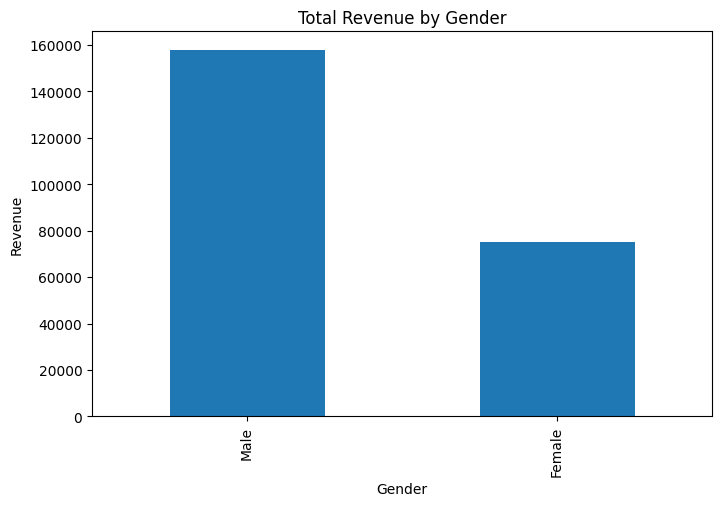

In [60]:
plt.figure(figsize=(8, 5))
total_revenue_by_gender.plot(kind='bar')
plt.title('Total Revenue by Gender')
plt.xlabel('Gender')
plt.ylabel('Revenue')
plt.show()

### Insight

**Male** customers contribute more than double the total revenue compared to female customers.
This gap is primarily driven by a higher number of male shoppers, not significantly higher spending per order.

In [61]:
avg_purchase_by_gender = (
    df.groupby('gender')['purchase_amount']
    .mean()
)
avg_purchase_by_gender

gender
Female    60.249199
Male      59.536199
Name: purchase_amount, dtype: float64

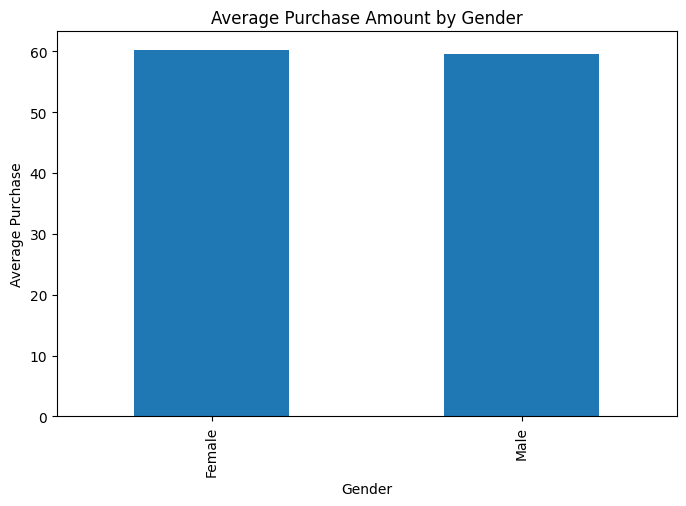

In [62]:
plt.figure(figsize=(8, 5))
avg_purchase_by_gender.plot(kind='bar')
plt.title('Average Purchase Amount by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Purchase')
plt.show()

### Insight

Although **male** customers dominate in volume, **female** customers have a slightly higher 
average purchase value. This suggests female shoppers tend to place higher-value orders, 
making them a strong segment for premium product positioning and targeted upselling.


In [63]:
gender_category_revenue = (
    df.groupby(['gender', 'category'])['purchase_amount']
    .sum()
    .reset_index()
)
gender_category_revenue

,gender,category,purchase_amount
0,Female,Accessories,23819
1,Female,Clothing,33636
2,Female,Footwear,11835
3,Female,Outerwear,5901
4,Male,Accessories,50381
5,Male,Clothing,70628
6,Male,Footwear,24258
7,Male,Outerwear,12623


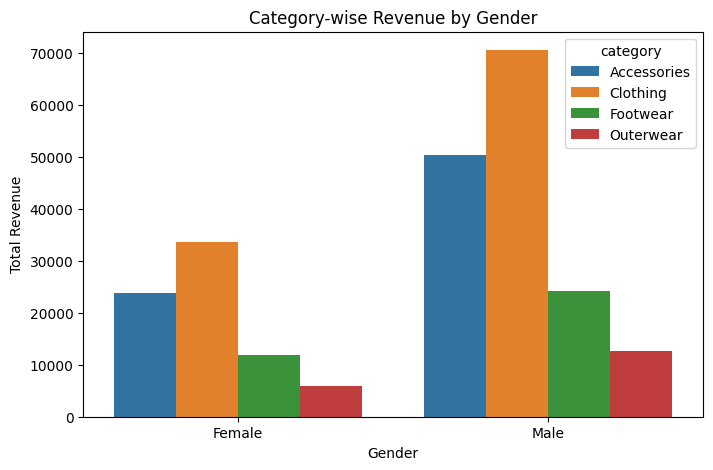

In [64]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=gender_category_revenue,
    x='gender',
    y='purchase_amount',
    hue='category'
)
plt.title('Category-wise Revenue by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Revenue')
plt.show()

### Insight

**Male** customers generate higher revenue across every product category, with the strongest dominance in **Clothing and Accessories**.
However, **female** customers still show meaningful participation, especially in Clothing, indicating potential for growth through targeted category-specific campaigns.

### Purchase Amount Distribution

This analysis examines how purchase amounts are distributed across all customers. 
Understanding the spread and shape of the distribution helps identify common spending 
ranges, skewness, and potential outliers.


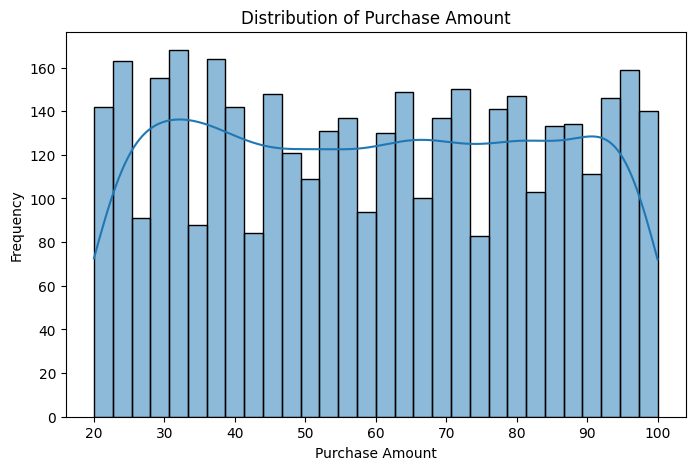

In [65]:
plt.figure(figsize=(8, 5))
sns.histplot(df['purchase_amount'], bins=30, kde=True)
plt.title('Distribution of Purchase Amount')
plt.xlabel('Purchase Amount')
plt.ylabel('Frequency')
plt.show()

#### Insights

The purchase amount distribution is fairly uniform across the range, with most 
transactions occurring between lower and higher price points without extreme 
concentration at a single value.

This suggests stable pricing across products and indicates that customers do not 
strongly favor a specific spending level, which provides flexibility in pricing 
and promotional strategies.


### Category-wise Revenue Analysis

This analysis evaluates total revenue generated by each product category to 
identify high-performing and low-performing categories, helping guide inventory, 
marketing, and product strategy decisions.


In [23]:
category_revenue = (
    df.groupby('category')['purchase_amount']
    .sum()
    .sort_values(ascending=False)
)
category_revenue

category
Clothing       104264
Accessories     74200
Footwear        36093
Outerwear       18524
Name: purchase_amount, dtype: int64

#### Insights

Clothing is the highest revenue-generating category, contributing a significant 
portion of total sales, followed by Accessories.

Footwear and Outerwear generate comparatively lower revenue, indicating potential 
opportunities for targeted promotions, product expansion, or pricing optimization 
to improve their performance.


**To better understand revenue contribution across categories, we visualize the 
category-wise revenue using a bar chart.**


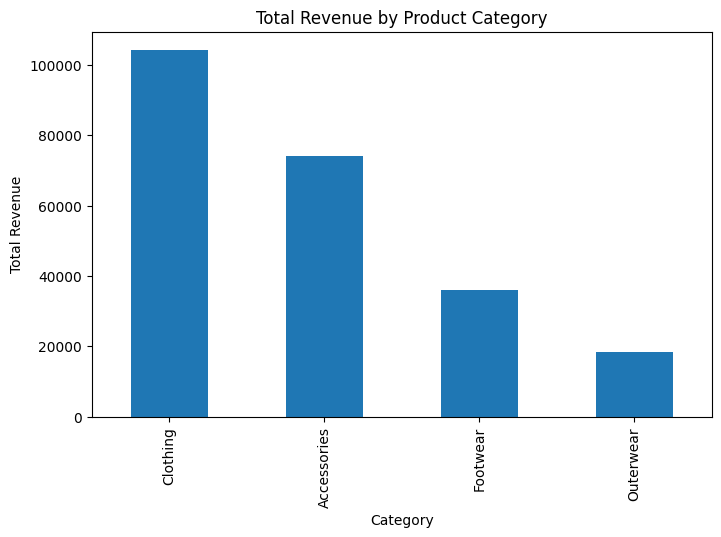

In [24]:
plt.figure(figsize=(8,5))
category_revenue.plot(kind='bar')
plt.title('Total Revenue by Product Category')
plt.xlabel('Category')
plt.ylabel('Total Revenue')
plt.show()

#### Insights

The bar chart clearly shows that Clothing dominates overall revenue, while 
Accessories also contribute substantially.

Lower revenue from Footwear and Outerwear suggests these categories may require 
strategic focus, such as improved marketing, seasonal campaigns, or product 
bundling, to increase sales.


### Discount Impact Analysis

This analysis examines the relationship between discounts and purchase amounts to 
understand whether offering discounts leads to higher customer spending.


In [25]:
df['discount_applied'].value_counts()

discount_applied
No     2223
Yes    1677
Name: count, dtype: int64

In [26]:
discount_impact = (
    df.groupby('discount_applied')['purchase_amount']
    .mean()
)

discount_impact


discount_applied
No     60.130454
Yes    59.279070
Name: purchase_amount, dtype: float64

#### Insights

The number of transactions without discounts is higher than those with discounts, 
indicating that a significant portion of customers are willing to purchase without 
price incentives.

The average purchase amount for discounted transactions is slightly lower than 
non-discounted transactions, suggesting that discounts do not significantly increase 
per-transaction spending and may primarily support customer acquisition or conversion 
rather than higher order value.


**To visually compare spending behavior, we plot the average purchase amount for 
discounted versus non-discounted transactions.**


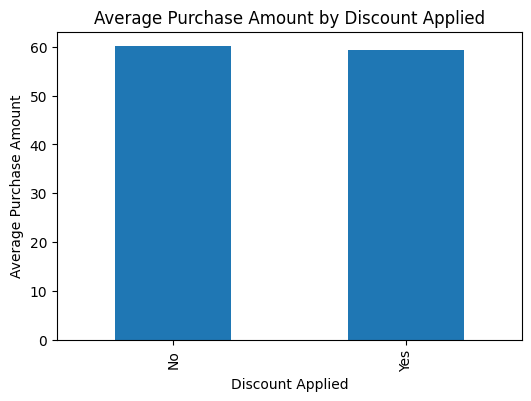

In [27]:
plt.figure(figsize=(6, 4))
discount_impact.plot(kind='bar')
plt.title('Average Purchase Amount by Discount Applied')
plt.xlabel('Discount Applied')
plt.ylabel('Average Purchase Amount')
plt.show()


#### Insights

The bar chart confirms that discounted purchases have a slightly lower average 
purchase amount compared to non-discounted purchases.

This indicates that discounts may encourage purchases but do not necessarily lead 
to higher transaction values, highlighting the importance of carefully balancing 
discount strategies to protect profit margins.


### Purchase Frequency / Loyalty Analysis

This analysis evaluates how frequently customers make purchases to identify 
one-time buyers versus repeat customers and assess customer loyalty patterns.


In [28]:
frequency_counts = df['frequency_of_purchases'].value_counts()
frequency_counts


frequency_of_purchases
Every 3 Months    584
Annually          572
Quarterly         563
Monthly           553
Bi-Weekly         547
Fortnightly       542
Weekly            539
Name: count, dtype: int64

#### Insights

The distribution of purchase frequency shows that customers are fairly evenly 
spread across different purchase intervals, with no single frequency segment 
dominating the customer base.

This suggests a balanced mix of occasional and frequent shoppers, indicating 
opportunities to encourage more frequent purchases through targeted engagement 
and retention strategies.


In [29]:
frequency_spending = (
    df.groupby('frequency_of_purchases')['purchase_amount']
    .mean()
    .sort_values(ascending=False)
)

frequency_spending


frequency_of_purchases
Bi-Weekly         60.694698
Annually          60.173077
Every 3 Months    60.082192
Quarterly         59.984014
Monthly           59.330922
Fortnightly       59.053506
Weekly            58.972171
Name: purchase_amount, dtype: float64

#### Insights

The average purchase amount across different purchase frequencies remains relatively 
consistent, with only minor variations between segments.

This indicates that increased purchase frequency does not necessarily lead to higher 
per-transaction spending, but frequent customers still contribute greater total 
revenue over time due to repeated purchases.


**To better visualize customer spending behavior across purchase frequency segments, 
we plot the average purchase amount by purchase frequency.**

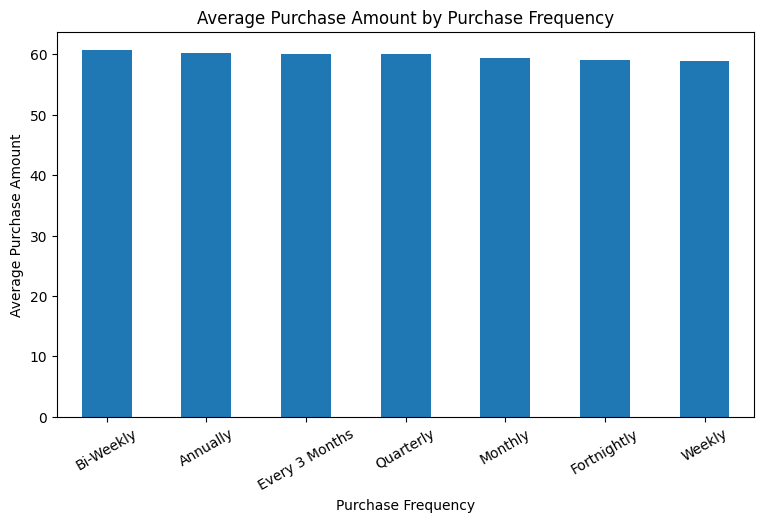

In [30]:
plt.figure(figsize=(9, 5))
frequency_spending.plot(kind='bar')
plt.title('Average Purchase Amount by Purchase Frequency')
plt.xlabel('Purchase Frequency')
plt.ylabel('Average Purchase Amount')
plt.xticks(rotation=30)
plt.show()


#### Insights

The bar chart shows that the average purchase amount remains relatively stable across 
all purchase frequency segments, with only minor variations between them.

This indicates that frequent customers do not necessarily spend more per transaction, 
but they are more valuable over time due to repeated purchases. Businesses can 
leverage this insight by focusing on customer retention strategies such as loyalty 
programs, subscriptions, and personalized offers to increase customer lifetime value.


### Seasonality Analysis

This analysis examines how customer purchasing behavior varies across different 
seasons to identify seasonal trends that can support inventory, pricing, and 
marketing strategies.


In [31]:
df['season'].value_counts()

season
Spring    999
Fall      975
Winter    971
Summer    955
Name: count, dtype: int64

In [32]:
season_revenue = (
    df.groupby('season')['purchase_amount']
    .sum()
    .sort_values(ascending=False)
)

season_revenue


season
Fall      60018
Spring    58679
Winter    58607
Summer    55777
Name: purchase_amount, dtype: int64

In [33]:
season_avg_spend = (
    df.groupby('season')['purchase_amount']
    .mean()
    .sort_values(ascending=False)
)

season_avg_spend

season
Fall      61.556923
Winter    60.357364
Spring    58.737738
Summer    58.405236
Name: purchase_amount, dtype: float64


**To better understand seasonal performance, we visualize total revenue across 
different seasons.**


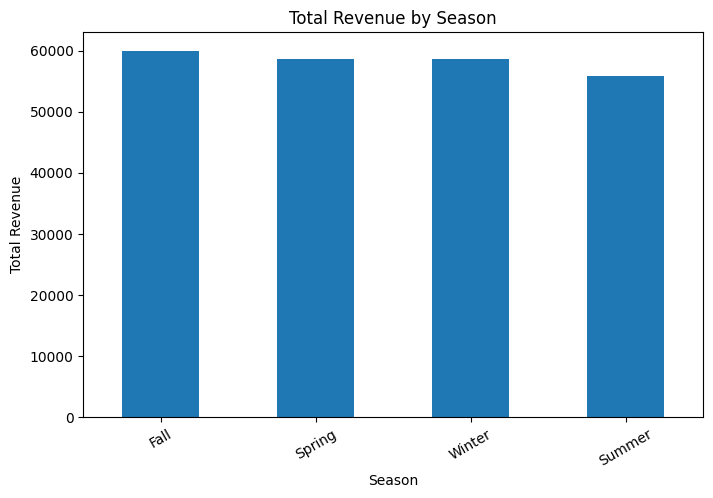

In [34]:
plt.figure(figsize=(8, 5))
season_revenue.plot(kind='bar')
plt.title('Total Revenue by Season')
plt.xlabel('Season')
plt.ylabel('Total Revenue')
plt.xticks(rotation=30)
plt.show()

#### Insights

The seasonal analysis shows that Fall generates the highest total revenue, followed 
closely by Spring and Winter, while Summer records comparatively lower revenue.

Additionally, the average purchase amount is highest during Fall and Winter, 
indicating stronger customer spending during these seasons. This suggests that 
customer demand peaks during cooler or festive periods.

From a business perspective, inventory planning and marketing efforts should be 
prioritized during high-performing seasons such as Fall and Winter, while Summer 
may benefit from targeted promotions or discounts to stimulate demand.


### 5. EDA Summary & Business Recommendations

This section summarizes key insights derived from the exploratory data analysis 
and provides actionable business recommendations based on data-driven findings.


#### Key Findings

1. **Customer Demographics**
   - Adult and Middle Aged customers form the largest customer segments.
   - Average purchase amount remains consistent across age groups, indicating 
     similar per-transaction spending behavior.

2. **Purchase Amount Distribution**
   - Purchase amounts are evenly distributed without extreme outliers.
   - This suggests stable pricing and predictable customer spending patterns.

3. **Category Performance**
   - Clothing is the highest revenue-generating category, followed by Accessories.
   - Footwear and Outerwear contribute relatively lower revenue.

4. **Discount Impact**
   - Discounted transactions do not show higher average purchase amounts compared 
     to non-discounted purchases.
   - Discounts appear to support conversion rather than increasing order value.

5. **Customer Loyalty**
   - Purchase frequency is evenly distributed across customer segments.
   - Average spending per transaction is stable across frequencies, indicating 
     that loyal customers drive value through repeat purchases.

6. **Seasonality**
   - Fall and Winter generate the highest revenue and average purchase amounts.
   - Summer shows comparatively lower revenue.


#### Business Recommendations

1. **Focus on Core Customer Segments**
   - Target Adult and Middle Aged customers with personalized campaigns, as they 
     represent the largest customer base.

2. **Category Optimization**
   - Continue investing in high-performing categories such as Clothing and 
     Accessories.
   - Improve Footwear and Outerwear performance through promotions, bundling, or 
     seasonal campaigns.

3. **Discount Strategy Optimization**
   - Use discounts strategically for customer acquisition and retention rather 
     than expecting higher per-order revenue.
   - Evaluate discount impact on profit margins before expanding discount programs.

4. **Strengthen Customer Loyalty**
   - Introduce loyalty programs, subscriptions, or personalized offers to increase 
     repeat purchase frequency and customer lifetime value.

5. **Seasonal Planning**
   - Increase inventory and marketing spend during Fall and Winter to capitalize 
     on peak demand.
   - Use targeted promotions during Summer to boost sales during low-demand periods.


## 6. Advanced Exploratory Data Analysis (EDA – Phase 2)

This section focuses on deeper analysis including outlier detection, 
customer satisfaction through review ratings, and geo-demographic 
shopping behavior to uncover more granular business insights.

6.1 **Outlier Analysis (IQR Method)**   
6.2 **Review Rating Analysis**   
6.3 **Geo-Demographic Analysis (Location × Category × Age Group)**   


### 6.1 Outlier Analysis (IQR Method)

Outlier analysis is performed to identify unusually high or low purchase amounts 
that may distort statistical analysis or indicate exceptional customer behavior. 
The Interquartile Range (IQR) method is used due to its robustness against extreme values.


In [35]:
Q1 = df['purchase_amount'].quantile(0.25)
Q3 = df['purchase_amount'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

lower_bound = max(0, lower_bound)

lower_bound, upper_bound

(0, np.float64(144.0))

Since purchase amounts cannot be negative in real-world scenarios, the lower 
bound is adjusted to zero to align statistical detection with business logic.

In [36]:
outliers = df[
    (df['purchase_amount'] < lower_bound) |
    (df['purchase_amount'] > upper_bound)
]

outliers.shape

(0, 19)

In [37]:
outlier_percentage = (outliers.shape[0] / df.shape[0]) * 100
outlier_percentage

0.0

The outlier detection results indicate that there are no purchase amounts lying 
outside the IQR-defined bounds. This suggests that customer spending behavior is 
well-distributed without extreme anomalies.


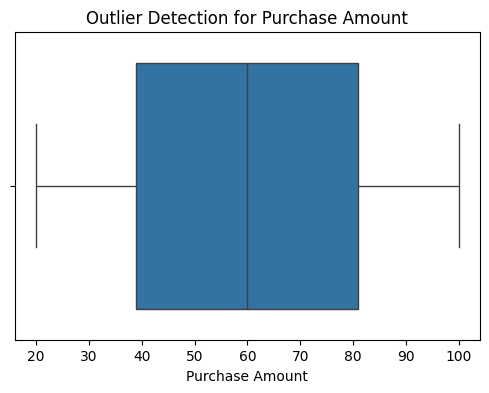

In [38]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['purchase_amount'])
plt.title('Outlier Detection for Purchase Amount')
plt.xlabel('Purchase Amount')
plt.show()


#### Insights

The boxplot confirms the absence of significant outliers in purchase amounts. 
This indicates a stable pricing structure and consistent customer spending behavior.

Since no extreme values are present, all transactions are retained for further 
analysis without the need for outlier treatment or removal. This ensures that 
aggregate metrics such as average purchase value remain reliable and unbiased.


### 6.2 Review Rating Analysis
This analysis explores customer review ratings to understand overall customer 
satisfaction and its potential relationship with purchasing behavior.


In [39]:
df['review_rating'].value_counts().sort_index()

review_rating
2.5     66
2.6    158
2.7    154
2.8    136
2.9    166
3.0    162
3.1    156
3.2    152
3.3    146
3.4    182
3.5    152
3.6    147
3.7    168
3.8    159
3.9    162
4.0    181
4.1    148
4.2    169
4.3    147
4.4    158
4.5    139
4.6    170
4.7    148
4.8    144
4.9    162
5.0     68
Name: count, dtype: int64

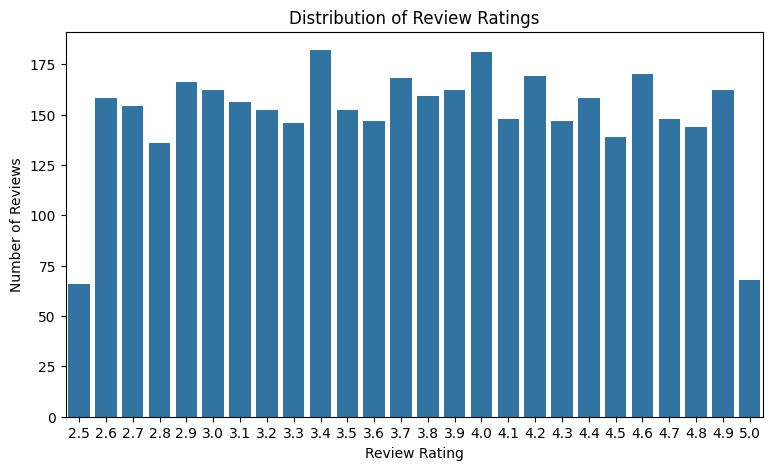

In [43]:
plt.figure(figsize=(9, 5))
sns.countplot(x='review_rating', data=df)
plt.title('Distribution of Review Ratings')
plt.xlabel('Review Rating')
plt.ylabel('Number of Reviews')
plt.show()

#### Insights

The distribution of review ratings shows that customer feedback is spread across a 
narrow and realistic range, primarily between 2.5 and 5.0. Most ratings cluster 
around the mid-to-high range (approximately 3.5 to 4.5), indicating generally 
positive customer satisfaction.

The absence of extremely low ratings suggests that customers are largely satisfied 
with their purchases, while the balanced distribution across rating levels indicates 
authentic and unbiased customer feedback rather than artificially inflated ratings.


In [45]:
rating_purchase = (
    df.groupby('review_rating')['purchase_amount']
    .mean()
)
rating_purchase

review_rating
2.5    62.287879
2.6    59.765823
2.7    59.363636
2.8    57.066176
2.9    56.198795
3.0    60.728395
3.1    58.782051
3.2    61.315789
3.3    59.794521
3.4    59.005495
3.5    58.072368
3.6    57.081633
3.7    60.244048
3.8    61.132075
3.9    58.913580
4.0    59.237569
4.1    61.959459
4.2    60.757396
4.3    59.673469
4.4    60.525316
4.5    59.489209
4.6    57.311765
4.7    59.283784
4.8    61.881944
4.9    63.746914
5.0    64.352941
Name: purchase_amount, dtype: float64

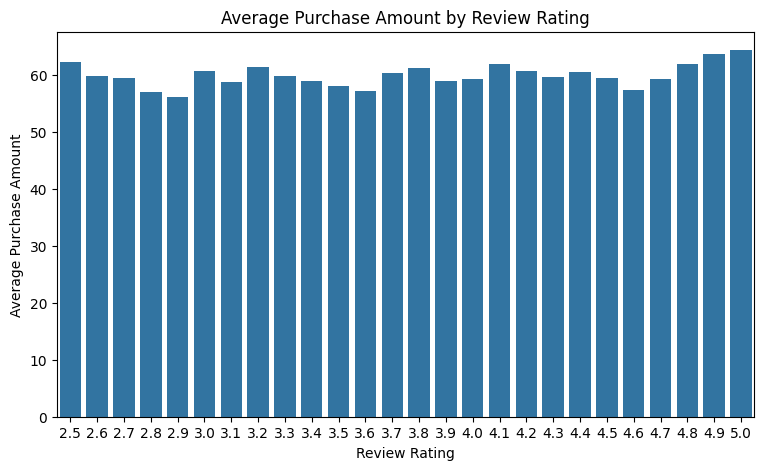

In [49]:
plt.figure(figsize=(9, 5))
sns.barplot(
    x=rating_purchase.index,
    y=rating_purchase.values
)
plt.title('Average Purchase Amount by Review Rating')
plt.xlabel('Review Rating')
plt.ylabel('Average Purchase Amount')
plt.show()

### Review Rating vs Purchase Amount – Key Insights

The analysis shows a **positive relationship** between review ratings and average purchase amount.

Key observations:
- Higher review ratings (4.5 – 5.0) are associated with **higher average purchase amounts**.
- Lower ratings tend to correlate with relatively lower spending.
- Although fluctuations exist, the overall trend suggests that **satisfied customers spend more**.

**Business Implication:**  
Customer satisfaction directly influences revenue. Improving product quality and customer experience can increase both **repeat purchases** and **average order value (AOV)**. High-rating customers should be targeted for loyalty programs and premium offerings.


In [53]:
category_rating = (
    df.groupby('category')['review_rating']
    .mean()
    .sort_values(ascending=False)
)
category_rating

category
Footwear       3.793823
Accessories    3.770242
Outerwear      3.745988
Clothing       3.721301
Name: review_rating, dtype: float64

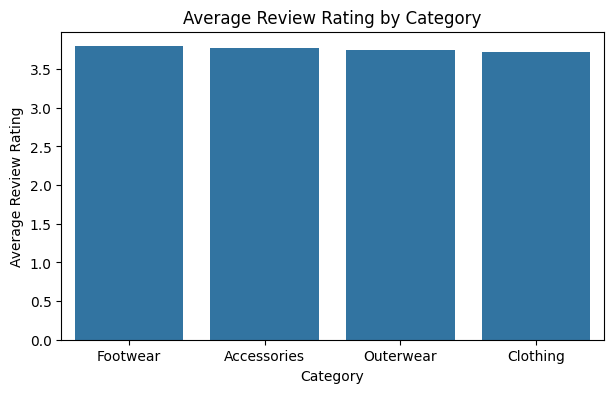

In [54]:
plt.figure(figsize=(7, 4))
sns.barplot(
    x=category_rating.index,
    y=category_rating.values
)
plt.title('Average Review Rating by Category')
plt.xlabel('Category')
plt.ylabel('Average Review Rating')
plt.show()

### Review Rating by Category – Key Insights

Average review ratings across product categories are relatively close, ranging between **3.72 and 3.79**, indicating consistent satisfaction levels.

Key observations:
- **Footwear** has the highest average rating, suggesting better customer perception.
- **Clothing** has slightly lower ratings compared to other categories.
- No category exhibits critically low satisfaction, indicating acceptable product quality overall.

**Business Implication:**  
While performance across categories is stable, categories with slightly lower ratings (e.g., Clothing) should be analyzed further for issues such as sizing, material quality, or return experience. High-performing categories can be leveraged in marketing campaigns and bundled promotions.


In [65]:
location_category_revenue = (
    df.groupby(['location', 'category'])['purchase_amount']
    .sum()
    .reset_index()
    .sort_values(by='purchase_amount', ascending=False)
)
location_category_revenue.head(10)

,location,category,purchase_amount
101,Montana,Clothing,2768
17,California,Clothing,2740
69,Louisiana,Clothing,2562
89,Minnesota,Clothing,2518
109,Nevada,Clothing,2515
49,Illinois,Clothing,2508
45,Idaho,Clothing,2472
141,Oklahoma,Clothing,2464
177,Vermont,Clothing,2426
13,Arkansas,Clothing,2413


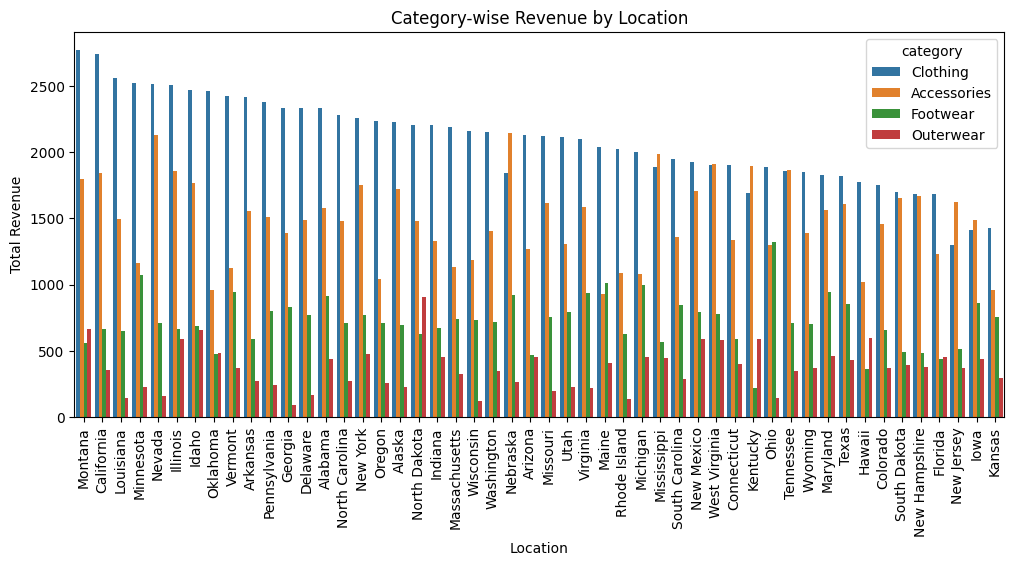

In [89]:
plt.figure(figsize=(12, 5))
sns.barplot(
    data=location_category_revenue,
    x='location',
    y='purchase_amount',
    hue='category'
)
plt.title('Category-wise Revenue by Location')
plt.xticks(rotation=90)
plt.xlabel('Location')
plt.ylabel('Total Revenue')
plt.show()

### Insights: Category-wise Revenue by Location

Clothing consistently emerges as the highest revenue-generating category across most locations, indicating strong and widespread demand. Accessories typically rank second, while Footwear and Outerwear contribute comparatively lower revenue.

This pattern suggests that core apparel products drive regional sales performance, while other categories may benefit from targeted promotions or bundling strategies depending on location-specific preferences.


In [78]:
age_category_revenue = (
    df.groupby(['age_group', 'category'])['purchase_amount']
    .sum()
    .reset_index()
)
age_category_revenue

C:\Users\mohda\AppData\Local\Temp\ipykernel_1632\1593827009.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['age_group', 'category'])['purchase_amount']


,age_group,category,purchase_amount
0,Young Adult,Accessories,10511
1,Young Adult,Clothing,16221
2,Young Adult,Footwear,4849
3,Young Adult,Outerwear,3049
4,Adult,Accessories,22000
5,Adult,Clothing,28864
6,Adult,Footwear,10195
7,Adult,Outerwear,4783
8,Middle Aged,Accessories,27179
9,Middle Aged,Clothing,39758


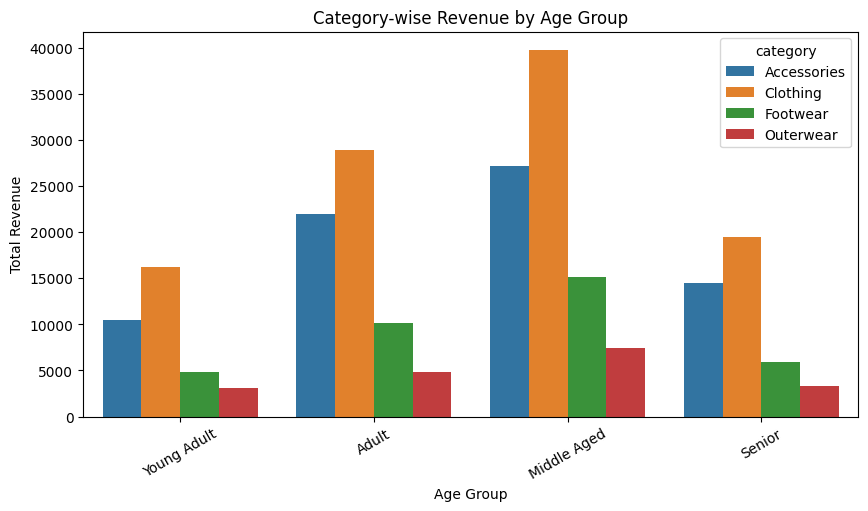

In [88]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=age_category_revenue,
    x='age_group',
    y='purchase_amount',
    hue='category'
)
plt.title('Category-wise Revenue by Age Group')
plt.xticks(rotation=30)
plt.xlabel('Age Group')
plt.ylabel('Total Revenue')
plt.show()

### Insights: Category-wise Revenue by Age Group

Middle Aged customers generate the highest total revenue across all product categories, particularly in Clothing and Accessories. Adult customers follow closely, while Young Adults and Seniors contribute relatively less.

This indicates that Middle Aged and Adult segments are the most commercially valuable customer groups, likely due to higher purchasing power and consistent shopping behavior. Marketing strategies should prioritize these age groups for premium offerings and loyalty programs.


In [82]:
location_age_revenue = (
    df.groupby(['location', 'age_group'])['purchase_amount']
    .sum()
    .reset_index()
    .sort_values(by='purchase_amount', ascending=False)
)
location_age_revenue.head(10)

C:\Users\mohda\AppData\Local\Temp\ipykernel_1632\1891125746.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['location', 'age_group'])['purchase_amount']


,location,age_group,purchase_amount
106,Nebraska,Middle Aged,2655
46,Idaho,Middle Aged,2434
198,Wyoming,Middle Aged,2383
18,California,Middle Aged,2340
138,Ohio,Middle Aged,2252
2,Alabama,Middle Aged,2230
102,Montana,Middle Aged,2202
122,New Mexico,Middle Aged,2190
133,North Dakota,Adult,2121
78,Maryland,Middle Aged,2082


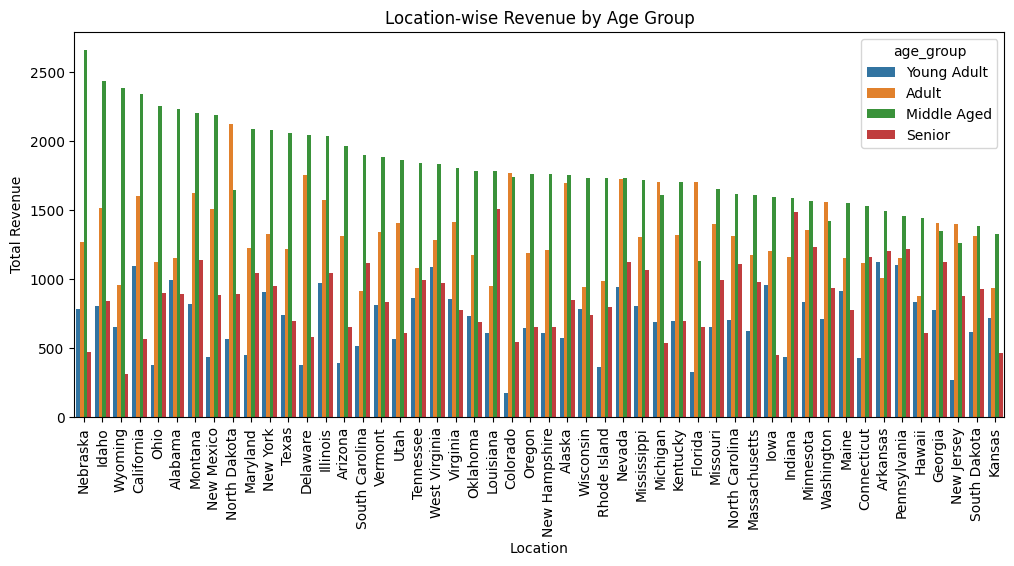

In [86]:
plt.figure(figsize=(12, 5))
sns.barplot(
    data=location_age_revenue,
    x='location',
    y='purchase_amount',
    hue='age_group'
)
plt.title('Location-wise Revenue by Age Group')
plt.xticks(rotation=90)
plt.xlabel('Location')
plt.ylabel('Total Revenue')
plt.show()

### Insights: Location-wise Revenue by Age Group

Across most locations, Middle Aged customers dominate revenue contribution, making them the most valuable demographic segment geographically. Adult customers also show strong presence in several regions, while Young Adults and Seniors tend to contribute moderately.

This geo-demographic pattern highlights opportunities for region-specific targeting, where marketing campaigns and inventory planning can be aligned with the dominant age group in each location to maximize revenue impact.
